# **Data Preprocessing :**

In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
VIDEO_DIR = Path("../video")

video_files = list(VIDEO_DIR.glob("*.mp4"))

video_files

[WindowsPath('../video/video.mp4')]

In [4]:
video_path = video_files[0]

print("Video:", video_path)

Video: ..\video\video.mp4


In [5]:
cap = cv2.VideoCapture(str(video_path))

if not cap.isOpened():
    raise ValueError(f"Could not open video: {video_path}")

print("Video loaded successfully")

Video loaded successfully


### Basic Video Info :

In [6]:
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print(f"FPS: {fps:.2f}")
print(f"Frames: {frame_count}")
print(f"Resolution: {width} x {height}")
print(f"Duration: {duration:.2f} seconds")

FPS: 30.00
Frames: 397
Resolution: 408 x 720
Duration: 13.23 seconds


### reading the frame and showing here :

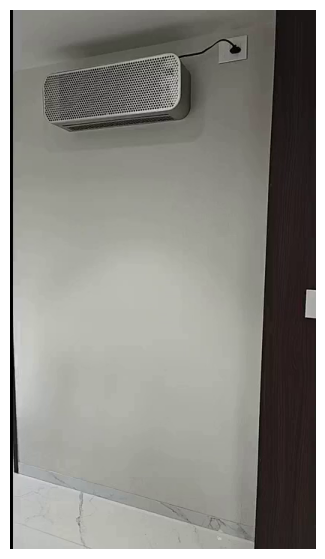

In [7]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

success, frame = cap.read()

if not success:
    raise ValueError("Could not read the first frame")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## **Function for Frame Extracting :**

In [8]:
import cv2
from pathlib import Path


def extract_frames(video_path, save_location, fps):
    """
    Extract frames from a video at a specified FPS.

    Args:
        video_path: Path to the input video.
        save_location: Folder where extracted frames will be saved.
        fps: Number of frames to extract per second.
    """

    video_path = Path(video_path)
    save_location = Path(save_location)

    save_location.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    original_fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0 or fps > original_fps:
        raise ValueError(
            f"fps must be between 0 and {original_fps:.2f}"
        )

    frame_interval = original_fps / fps

    frame_number = 0
    saved_frame_number = 0

    while True:
        success, frame = cap.read()

        if not success:
            break

        # Save frame at the required FPS
        if frame_number >= saved_frame_number * frame_interval:

            frame_path = save_location / f"frame_{saved_frame_number:06d}.jpg"

            cv2.imwrite(str(frame_path), frame)

            saved_frame_number += 1

        frame_number += 1

    cap.release()

    print(f"Original FPS : {original_fps:.2f}")
    print(f"Extraction FPS: {fps}")
    print(f"Frames saved : {saved_frame_number}")
    print(f"Saved to     : {save_location}")

In [9]:
extract_frames(
    "../video/video.mp4",
    "../data/frames",
    fps=25
)

Original FPS : 30.00
Extraction FPS: 25
Frames saved : 331
Saved to     : ..\data\frames
